# Momentum tail-risk baseline EDA

Point-in-time Phase 1 review of the approved 5-day and 20-day momentum-factor tail-loss labels. Development results use three purged, non-overlapping six-year tests. Holdout results were generated once after the model specification was frozen. The 20-day holdout contains only one episode and is interpreted descriptively.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "data" / "processed").exists():
    ROOT = ROOT.parent
DATA = ROOT / "data" / "processed"
OUTPUTS = ROOT / "outputs"
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 30)

momentum = pd.read_parquet(DATA / "french_momentum_factor_daily.parquet")
legs = pd.read_parquet(DATA / "momentum_leg_structure.parquet")
features = pd.read_parquet(DATA / "market_features.parquet")
labels = {h: pd.read_parquet(DATA / f"momentum_labels_h{h}.parquet") for h in (5, 20)}
metrics = pd.read_csv(OUTPUTS / "baseline_metrics.csv")
calibration = pd.read_csv(OUTPUTS / "calibration_table.csv")
print(f"Data through {momentum.date.max().date()}; {len(momentum):,} momentum rows")

Data through 2026-05-29; 26,152 momentum rows


## Momentum wealth and episode onsets

Episode markers are descriptive label outcomes, not model inputs.

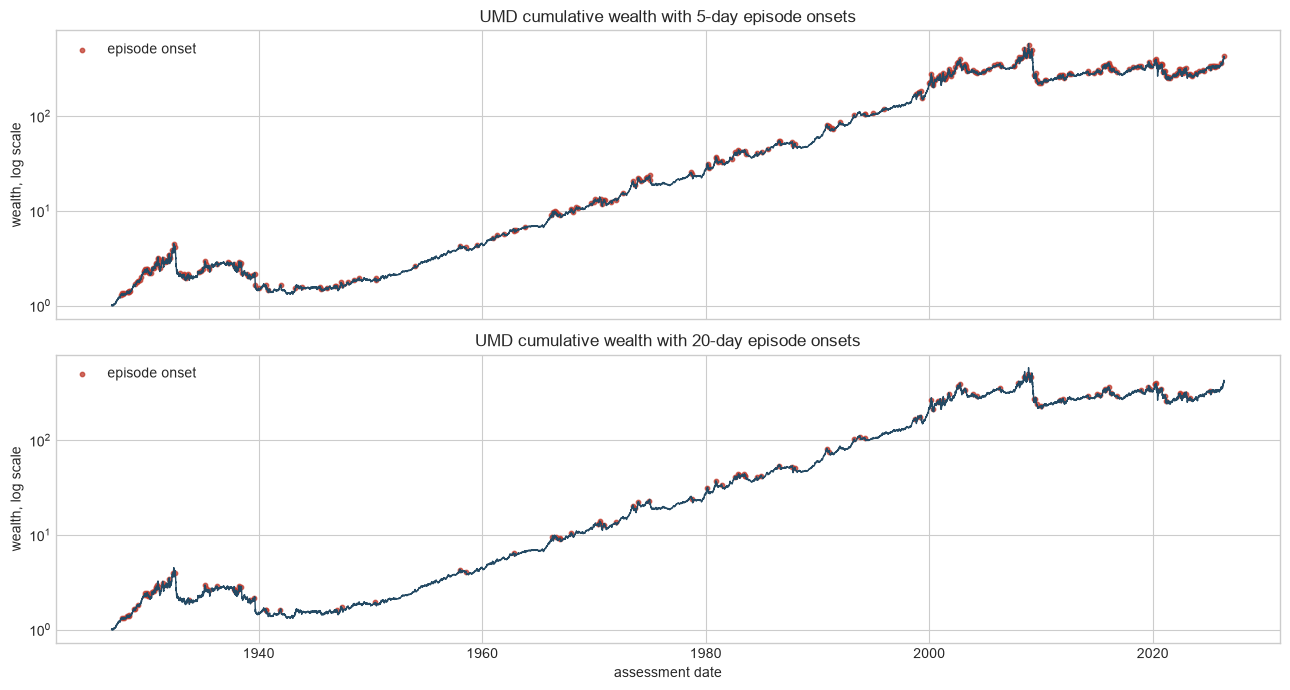

In [2]:
wealth = momentum[["date", "umd_return"]].copy()
wealth["umd_wealth"] = np.exp(np.log1p(wealth["umd_return"]).cumsum())
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for ax, horizon in zip(axes, (5, 20)):
    onset = labels[horizon].loc[labels[horizon]["event_onset"].fillna(False), ["date"]]
    marked = onset.merge(wealth[["date", "umd_wealth"]], on="date", how="left")
    ax.plot(wealth["date"], wealth["umd_wealth"], color="#244a64", linewidth=1.0)
    ax.scatter(marked["date"], marked["umd_wealth"], color="#c0392b", s=10, alpha=0.75, label="episode onset")
    ax.set_yscale("log")
    ax.set_title(f"UMD cumulative wealth with {horizon}-day episode onsets")
    ax.set_ylabel("wealth, log scale")
    ax.legend(loc="upper left")
axes[-1].set_xlabel("assessment date")
fig.tight_layout()
plt.show()

## Winner and loser legs inside labeled episodes

,horizon_days,state,rows,winner_mean_daily,loser_mean_daily,loser_minus_winner_mean
0,5,event day,1295,0.001370,0.003423,0.002053
1,5,non-event day,24596,0.000616,0.000239,-0.000376
2,20,event day,1340,0.000987,0.002268,0.001282
3,20,non-event day,24521,0.000635,0.000297,-0.000337


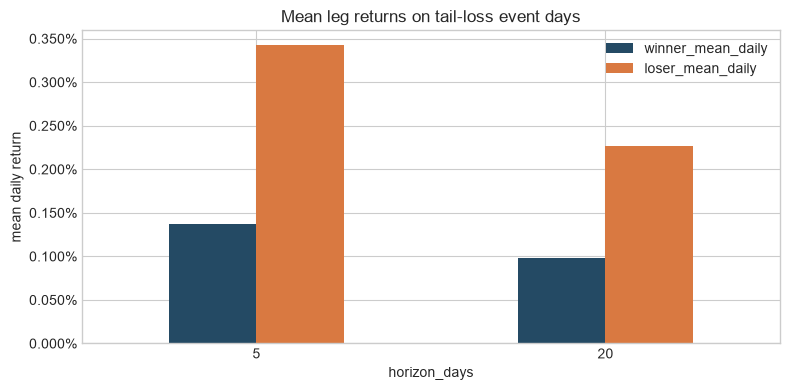

In [3]:
leg_rows = []
for horizon in (5, 20):
    target = f"mom_tail_loss_{horizon}"
    joined = legs[["date", "winner_leg_return", "loser_leg_return"]].merge(
        labels[horizon][["date", target]], on="date", how="inner"
    ).dropna(subset=[target])
    joined["episode_state"] = np.where(joined[target].astype(bool), "event day", "non-event day")
    for state, group in joined.groupby("episode_state"):
        leg_rows.append({
            "horizon_days": horizon,
            "state": state,
            "rows": len(group),
            "winner_mean_daily": group.winner_leg_return.mean(),
            "loser_mean_daily": group.loser_leg_return.mean(),
            "loser_minus_winner_mean": (group.loser_leg_return - group.winner_leg_return).mean(),
        })
leg_summary = pd.DataFrame(leg_rows)
display(leg_summary.round({"winner_mean_daily": 6, "loser_mean_daily": 6, "loser_minus_winner_mean": 6}))
event_legs = leg_summary[leg_summary.state.eq("event day")].set_index("horizon_days")
event_legs[["winner_mean_daily", "loser_mean_daily"]].plot.bar(
    figsize=(8, 4), color=["#244a64", "#d97941"], title="Mean leg returns on tail-loss event days"
)
plt.ylabel("mean daily return")
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Feature distributions: 5-day event versus non-event rows

These are unconditional descriptive distributions, not causal estimates.

,feature,state,rows,q25,median,q75
0,mom_return_63d,event,1295,-0.030691,0.032989,0.097769
1,mom_return_63d,non-event,24596,-0.015606,0.016343,0.049501
2,mom_vol_21d,event,1295,0.006417,0.009663,0.014889
3,mom_vol_21d,non-event,24596,0.003051,0.004543,0.007231
4,vix_close,event,680,20.542500,24.555000,30.240000
5,vix_close,non-event,8481,13.770000,17.190000,21.980000
6,mkt_return_504d,event,1268,-0.227042,0.077134,0.277256
7,mkt_return_504d,non-event,24376,0.096028,0.253387,0.453208
8,stress_rebound,event,1268,0.000000,0.000000,0.000000
9,stress_rebound,non-event,24376,0.000000,0.000000,0.000000


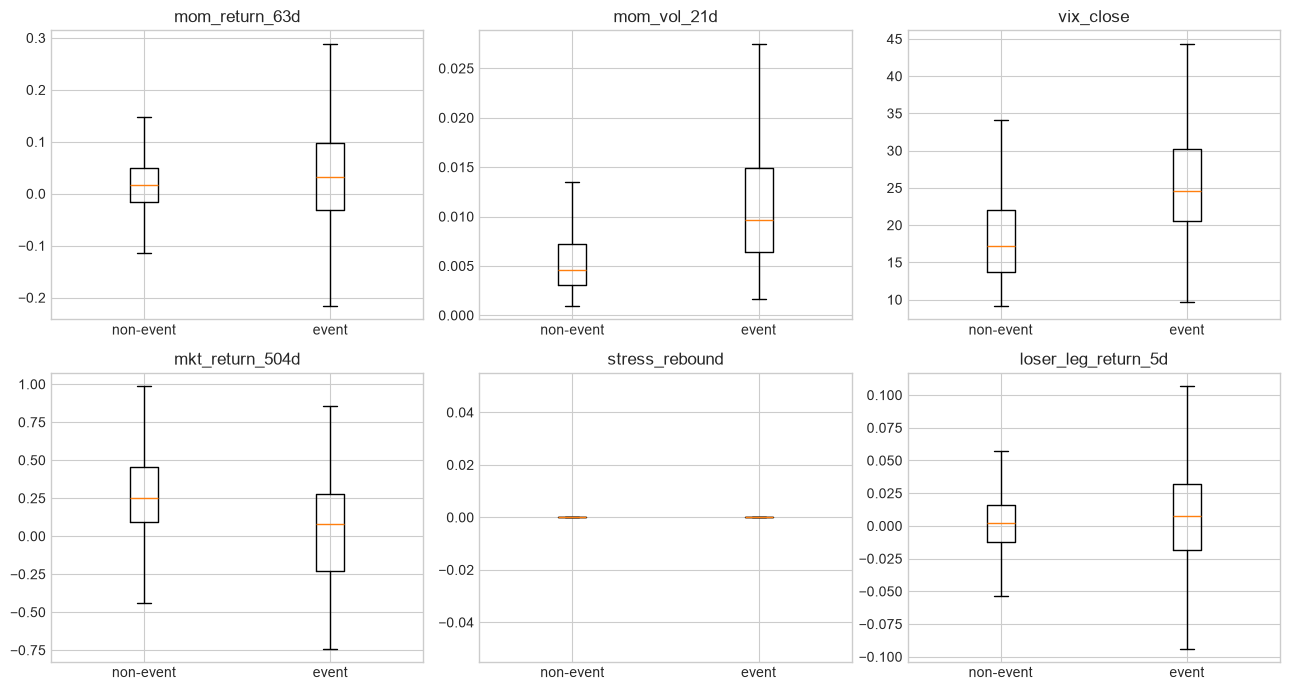

In [4]:
selected = ["mom_return_63d", "mom_vol_21d", "vix_close", "mkt_return_504d", "stress_rebound", "loser_leg_return_5d"]
feature_event = features[["date", *selected]].merge(
    labels[5][["date", "mom_tail_loss_5"]], on="date", how="inner"
).dropna(subset=["mom_tail_loss_5"])
feature_event["state"] = np.where(feature_event.mom_tail_loss_5.astype(bool), "event", "non-event")
summary_rows = []
for feature in selected:
    for state, group in feature_event.groupby("state"):
        values = group[feature].dropna()
        summary_rows.append({"feature": feature, "state": state, "rows": len(values), "q25": values.quantile(.25), "median": values.median(), "q75": values.quantile(.75)})
display(pd.DataFrame(summary_rows).round({"q25": 6, "median": 6, "q75": 6}))
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, feature in zip(axes.flat, selected):
    groups = [feature_event.loc[feature_event.state.eq(state), feature].dropna() for state in ("non-event", "event")]
    ax.boxplot(groups, tick_labels=["non-event", "event"], showfliers=False)
    ax.set_title(feature)
fig.tight_layout()
plt.show()

## Baseline ladder results

B0 is the purged-training matured event rate, B1 is the panic-state logistic baseline, and B2 uses all Task 3 market features. ROC-AUC is secondary; log loss and Brier score assess probability quality.

In [5]:
metric_columns = ["scope", "horizon_days", "baseline", "rows", "event_days", "event_episodes", "log_loss", "brier_score", "pr_auc", "roc_auc", "calibration_intercept", "calibration_slope", "event_capture_top_risk_decile"]
metric_display = metrics[metric_columns].sort_values(["scope", "horizon_days", "baseline"]).copy()
display(metric_display.round({"log_loss": 4, "brier_score": 4, "pr_auc": 4, "roc_auc": 4, "calibration_intercept": 3, "calibration_slope": 3, "event_capture_top_risk_decile": 4}))

,scope,horizon_days,baseline,rows,event_days,event_episodes,log_loss,brier_score,pr_auc,roc_auc,calibration_intercept,calibration_slope,event_capture_top_risk_decile
0,development,5,B0,4528,416,99,0.3343,0.0861,0.0785,0.3984,-4.180,-0.644,0.0216
1,development,5,B1,4528,416,99,0.3431,0.0895,0.3005,0.7707,-1.533,0.369,0.3558
2,development,5,B2,4528,416,99,0.9440,0.1685,0.2798,0.7880,-2.212,0.177,0.3510
3,development,20,B0,4528,404,33,0.3334,0.0842,0.0762,0.3885,-4.157,-0.600,0.0149
4,development,20,B1,4528,404,33,0.2966,0.0806,0.3737,0.8106,-1.344,0.464,0.4257
5,development,20,B2,4528,404,33,0.6133,0.1130,0.2485,0.7396,-1.787,0.172,0.3762
6,holdout,5,B0,748,31,17,0.1831,0.0410,0.0414,0.5000,-0.660,NaN,0.0968
7,holdout,5,B1,748,31,17,0.1712,0.0397,0.0966,0.6357,0.320,1.273,0.1290
8,holdout,5,B2,748,31,17,0.1715,0.0402,0.0785,0.6550,-1.040,0.739,0.1935
9,holdout,20,B0,733,9,1,0.1070,0.0158,0.0123,0.5000,-1.846,NaN,0.0000


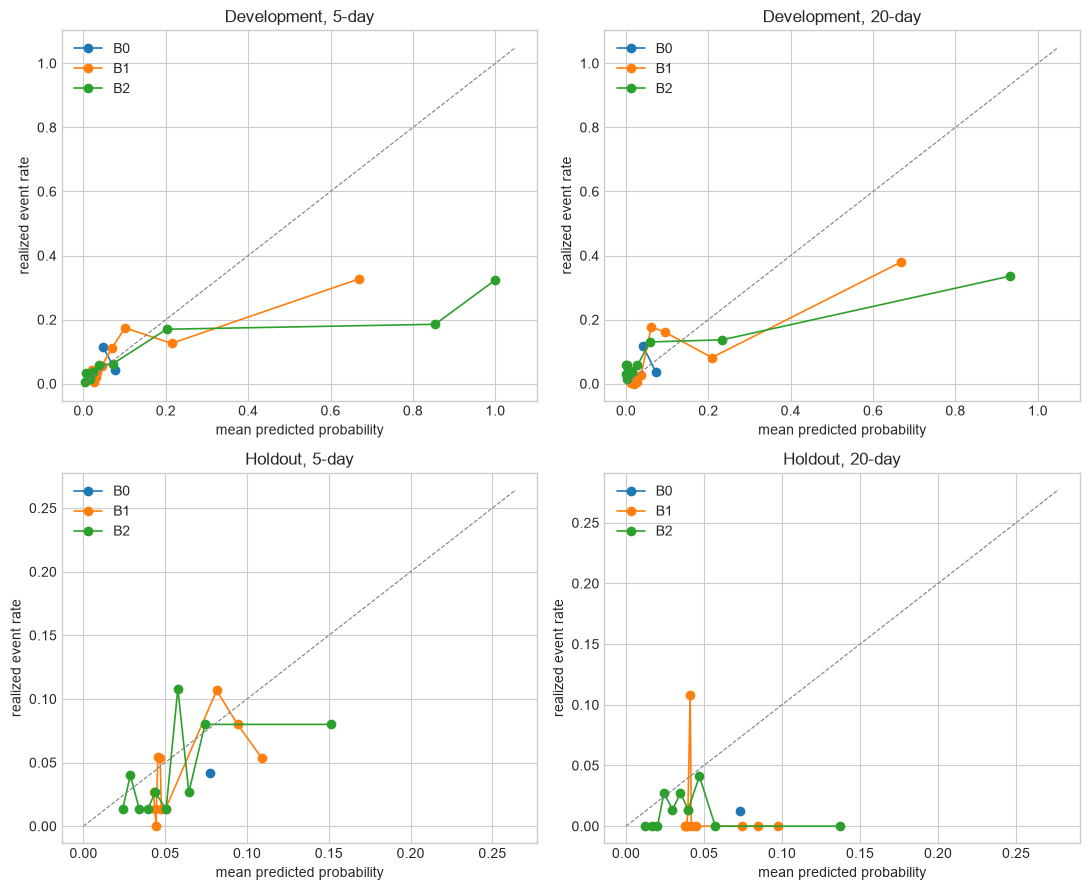

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharex=False, sharey=False)
for ax, (scope, horizon) in zip(axes.flat, [("development", 5), ("development", 20), ("holdout", 5), ("holdout", 20)]):
    subset = calibration[(calibration.scope.eq(scope)) & (calibration.horizon_days.eq(horizon))]
    for baseline, group in subset.groupby("baseline"):
        ax.plot(group.predicted_probability_mean, group.realized_event_rate, marker="o", linewidth=1.2, label=baseline)
    limit = max(subset.predicted_probability_max.max(), subset.realized_event_rate.max()) * 1.05
    ax.plot([0, limit], [0, limit], linestyle="--", color="gray", linewidth=.8)
    ax.set_title(f"{scope.title()}, {horizon}-day")
    ax.set_xlabel("mean predicted probability")
    ax.set_ylabel("realized event rate")
    ax.legend()
fig.tight_layout()
plt.show()

## Reading the evidence

- B1 provides the cleanest development probability baseline, especially for the 20-day target.
- B2 often improves ranking but produces unstable out-of-time probability levels in early development folds; calibration is its main weakness.
- The 5-day holdout supports modest ranking value, but absolute event rates are low.
- The single 20-day holdout episode is inadequate for a strong ranking or calibration conclusion.
- No classification or alert threshold is selected in Phase 1.